# HomeWork -4
## Objective
 In this homework, you will design a python class that encapsulates common univariate/bivariate analysis tasks. You will practice object oriented programing (OOP) while applying descriptive statistics and visualization to summarize your data and explore the relationship between two variables. 
 
 - Use the example provided in the class activity and expand it. The initializer of the class should take data and print out its shape and column names. 
 - Additionally, your class should include at least 5 methods (function) to do either univariate or bivariate analysis of your choice. 
 - Provide markdowns or comments for each part of your code.  

  - Create an instance of your class using Penguin data and use it to analyze it.
  
  - For each analysis you perform, write 1-2 sentence before that function call that clearly state
    the question you are trying to answer with that analysis. For example: "In this analysis I want to see what is the average mass for each species." 

  


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [58]:
df = sns.load_dataset('penguins')
print(df.shape)
df.head()

(344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [60]:
#Defining the class
class PenguinAnalyzer:
    def __init__(self, data):
        # Store data and print
        self.df = data
        print(f"Dataset Shape: {self.df.shape}")
        print(f"Columns: {list(self.df.columns)}")
        
    # Method 1- Univariate
    def plot_dist(self, col):
        sns.histplot(self.df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()
    
    # Method 2- Univariate
    def get_stats(self, col):
        return self.df[col].describe()
    
    # Method 3- Univariate
    def plot_count(self, col):
        sns.countplot(data=self.df, x=col)
        plt.title(f"Count of {col}")
        plt.show()
    
    # Method 4- Bivariate
    def plot_scatter(self, col1, col2):
        sns.scatterplot(data=self.df, x=col1, y=col2, hue='species')
        plt.title(f"{col1} vs {col2}")
        plt.show()
    
    # Method 5- Bivariate
    def plot_comparison(self, cat_col, num_col):
        sns.boxplot(data=self.df, x=cat_col, y=num_col)
        plt.title(f"{num_col} by {cat_col}")
        plt.show()

In [61]:
#Create an instance
analyzer = PenguinAnalyzer(df)

Dataset Shape: (344, 7)
Columns: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']


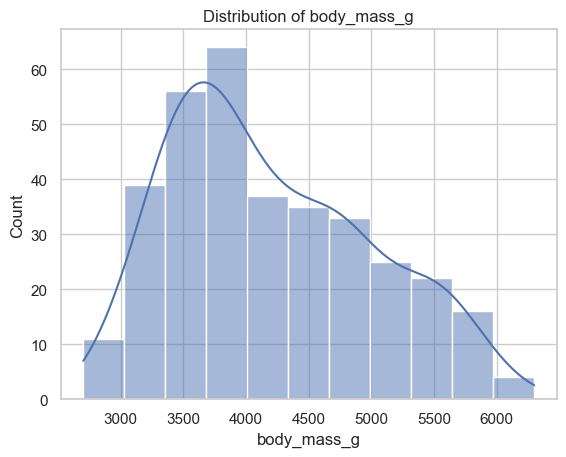

In [62]:
#This is a distribution plot for each penguin's body mass. It found that the average weight of the penguins recorded is around 350 grams
analyzer.plot_dist('body_mass_g')

In [63]:
# This function is getting the basic statistics for their bill lengths. It shows the total counted, average length, minimum, and maximum, etc.
analyzer.get_stats('bill_length_mm')

count    342.000000
mean      43.921930
std        5.459584
min       32.100000
25%       39.225000
50%       44.450000
75%       48.500000
max       59.600000
Name: bill_length_mm, dtype: float64

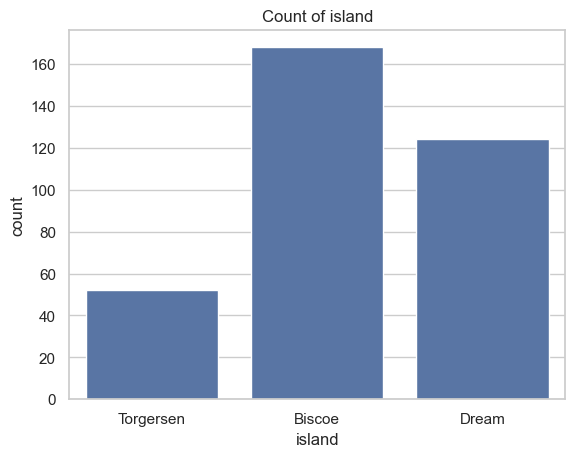

In [64]:
# This count plot shows how many penguins were recorded on each island. The plot shows that more penguins were recorded at Biscoe Island.
analyzer.plot_count('island')

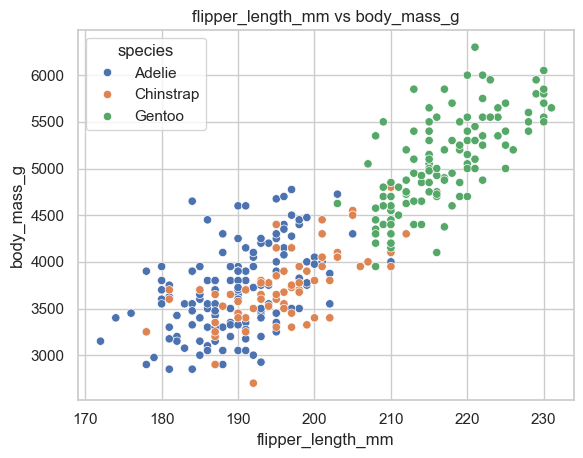

In [65]:
#This scatterplot shows the correlation between flipper length and body mass, comparing them. It shows that the larger the flipper length is, the higher their body mass, and vice versa (across all three species).
analyzer.plot_scatter('flipper_length_mm', 'body_mass_g')

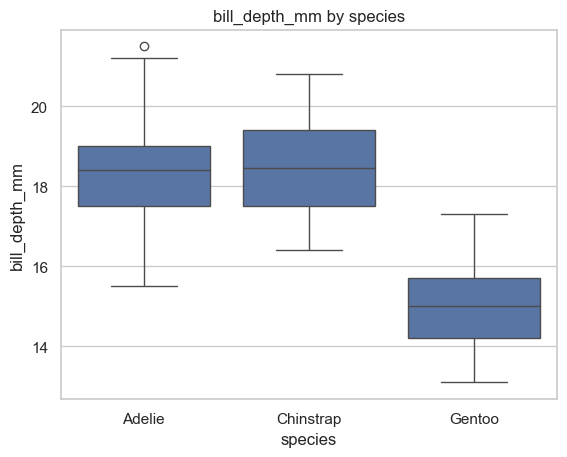

In [66]:
#This box plot compares the bill depth between three species to see which has the largest bill depth. It shows that the chinstrap species is the highest leading, Adelies are not far from them, and Gentoos are significantly shorter in bill depth. 
analyzer.plot_comparison('species', 'bill_depth_mm')